# Cross-dataset test: four RUGD-trained models on ORFD

This notebook evaluates four RUGD-trained binary segmentation models directly on the ORFD testing split:

- U-Net
- DeepLabV3+
- SegFormer-B0
- ROD (EfficientSAM-S encoder + ROD segmentation decoder)

This is a **zero-shot cross-dataset experiment**:

**RUGD training → ORFD testing**

No ORFD training or fine-tuning is performed in this notebook.

For ORFD:
- raw value `0` → non-traversable (`0`);
- raw value `128` → unreachable / ignore (`255`);
- raw value `255` → traversable (`1`).

The RUGD model output convention is aligned as:

- non-ground (`0`) ↔ non-traversable (`0`);
- ground (`1`) ↔ traversable (`1`).

This alignment is approximate because semantic ground and physical traversability are related but not identical concepts.

In [1]:
# Install the same model library used by the original baseline notebooks.
!pip -q install segmentation-models-pytorch timm

# Clone the original ROD repository.
import os
import sys

ROD_REPO = "/content/offroad_roadseg"

if not os.path.exists(ROD_REPO):
    !git clone --depth 1 https://github.com/ict-ans-617/offroad_roadseg.git {ROD_REPO}

if ROD_REPO not in sys.path:
    sys.path.insert(0, ROD_REPO)

print("ROD repository:", ROD_REPO)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.6 MB/s eta 0:00:00
Cloning into '/content/offroad_roadseg'...
remote: Enumerating objects: 80, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 80 (delta 17), reused 78 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (80/80), 4.32 MiB | 36.27 MiB/s, done.
Resolving deltas: 100% (17/17), done.
ROD repository: /content/offroad_roadseg


In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## 1. Configuration

In [3]:
from pathlib import Path

# ORFD testing archive.
ORFD_TEST_ZIP = Path(
    "/content/drive/MyDrive/IRP/01_data/raw/ORFD/testing.zip"
)

# RUGD-trained checkpoints.
# Unified with the reorganised in-domain RUGD experiment directory.
CHECKPOINTS = {
    "U-Net": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "unet_resnet34_rugd_binary_ground_best_20epochs.pth"
    ),
    "DeepLabV3+": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "deeplabv3plus_resnet34_rugd_binary_ground_best_20epochs.pth"
    ),
    "SegFormer-B0": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "segformer_b0_rugd_binary_ground_best_20epochs.pth"
    ),
    "ROD": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "rod_rugd_binary_ground_best_20epochs.pth"
    ),
}

LOCAL_DATA_ROOT = Path("/content/orfd_cross_dataset_test")

# Results are written directly to Google Drive.
RESULTS_ROOT = Path(
    "/content/drive/MyDrive/IRP/03_cross_dataset/rugd_to_orfd"
)

NON_TRAVERSABLE_CLASS = 0
TRAVERSABLE_CLASS = 1
IGNORE_INDEX = 255
NUM_CLASSES = 2

BATCH_SIZE = 8
ROD_BATCH_SIZE = 1
NUM_WORKERS = 2
PIN_MEMORY = True

# Set an integer such as 50 for a quick pipeline check.
MAX_TEST_SAMPLES = None

MODEL_CONFIGS = {
    "U-Net": {
        "input_size": (512, 512),
        "normalization": "imagenet",
        "encoder_name": "resnet34",
        "preprocess_mode": "direct_resize",
    },
    "DeepLabV3+": {
        "input_size": (512, 512),
        "normalization": "imagenet",
        "encoder_name": "resnet34",
        "encoder_output_stride": 16,
        "preprocess_mode": "direct_resize",
    },
    "SegFormer-B0": {
        "input_size": (512, 512),
        "normalization": "imagenet",
        "encoder_name": "mit_b0",
        "preprocess_mode": "direct_resize",
    },
    "ROD": {
        "input_size": (512, 512),
        "normalization": "rod_imagenet_255",
        "encoder_name": "EfficientSAM-S",
        "preprocess_mode": "aspect_ratio_pad",
        "encoder_input_size": (1024, 1024),
    },
}

print("ORFD test ZIP:", ORFD_TEST_ZIP)

for model_name, checkpoint_path in CHECKPOINTS.items():
    print(f"{model_name}: {checkpoint_path}")

ORFD test ZIP: /content/drive/MyDrive/IRP/01_data/raw/ORFD/testing.zip
U-Net: /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/unet_resnet34_rugd_binary_ground_best_20epochs.pth
DeepLabV3+: /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/deeplabv3plus_resnet34_rugd_binary_ground_best_20epochs.pth
SegFormer-B0: /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/segformer_b0_rugd_binary_ground_best_20epochs.pth
ROD: /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/rod_rugd_binary_ground_best_20epochs.pth


## 2. Validate paths and extract the ORFD testing split

In [4]:
import shutil
import zipfile

if not ORFD_TEST_ZIP.exists():
    raise FileNotFoundError(
        f"ORFD testing ZIP not found: {ORFD_TEST_ZIP}\n"
        "Update ORFD_TEST_ZIP to the correct Google Drive path."
    )

for model_name, checkpoint_path in CHECKPOINTS.items():
    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"{model_name} checkpoint not found: {checkpoint_path}"
        )

RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
LOCAL_DATA_ROOT.mkdir(parents=True, exist_ok=True)

EXTRACT_DIR = LOCAL_DATA_ROOT / "extracted"

def split_has_sequences(directory: Path) -> bool:
    if not directory.exists():
        return False

    return any(
        path.is_dir()
        and (path / "image_data").exists()
        and (path / "gt_image").exists()
        for path in directory.iterdir()
    )

if not split_has_sequences(EXTRACT_DIR / "testing"):
    if EXTRACT_DIR.exists():
        shutil.rmtree(EXTRACT_DIR)

    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

    print("Extracting:", ORFD_TEST_ZIP)
    with zipfile.ZipFile(ORFD_TEST_ZIP, "r") as archive:
        archive.extractall(EXTRACT_DIR)
else:
    print("Testing split is already extracted.")

candidate_roots = [
    EXTRACT_DIR / "testing",
    EXTRACT_DIR,
]

TEST_ROOT = None

for candidate in candidate_roots:
    if split_has_sequences(candidate):
        TEST_ROOT = candidate
        break

if TEST_ROOT is None:
    nested = [
        path for path in EXTRACT_DIR.rglob("testing")
        if path.is_dir() and split_has_sequences(path)
    ]

    if len(nested) == 1:
        TEST_ROOT = nested[0]

if TEST_ROOT is None:
    preview = [
        str(path.relative_to(EXTRACT_DIR))
        for path in list(EXTRACT_DIR.rglob("*"))[:40]
    ]
    raise RuntimeError(
        "Could not locate the extracted ORFD testing sequences. "
        f"First extracted entries: {preview}"
    )

print("ORFD testing root:", TEST_ROOT)

Extracting: /content/drive/MyDrive/IRP/01_data/raw/ORFD/testing.zip
ORFD testing root: /content/orfd_cross_dataset_test/extracted/testing


## 3. Match ORFD RGB images and masks

In [5]:
import re
from collections import defaultdict

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"
}

def list_images(root: Path):
    return sorted(
        path for path in root.rglob("*")
        if path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
    )

def canonical_stem(path: Path) -> str:
    stem = path.stem.lower()

    suffix_patterns = [
        r"_fillcolor$",
        r"_label_color$",
        r"_label$",
        r"_mask$",
        r"_gt$",
        r"_rgb$",
        r"_image$",
    ]

    changed = True
    while changed:
        changed = False

        for pattern in suffix_patterns:
            updated = re.sub(pattern, "", stem)

            if updated != stem:
                stem = updated
                changed = True

    return stem

pairs = []
pairing_reports = []

sequence_dirs = sorted(
    path for path in TEST_ROOT.iterdir()
    if path.is_dir()
)

print("Sequences:", len(sequence_dirs))

for sequence_dir in sequence_dirs:
    image_root = sequence_dir / "image_data"
    mask_root = sequence_dir / "gt_image"

    if not image_root.exists() or not mask_root.exists():
        pairing_reports.append({
            "sequence": sequence_dir.name,
            "images": 0,
            "masks": 0,
            "pairs": 0,
            "status": "missing image_data or gt_image",
        })
        continue

    image_paths = list_images(image_root)
    mask_paths = list_images(mask_root)

    image_index = defaultdict(list)
    mask_index = defaultdict(list)

    for image_path in image_paths:
        image_index[canonical_stem(image_path)].append(image_path)

    for mask_path in mask_paths:
        mask_index[canonical_stem(mask_path)].append(mask_path)

    common_keys = sorted(set(image_index) & set(mask_index))
    duplicate_keys = []

    for key in common_keys:
        if len(image_index[key]) != 1 or len(mask_index[key]) != 1:
            duplicate_keys.append(key)
            continue

        pairs.append({
            "sequence": sequence_dir.name,
            "stem": key,
            "image_path": image_index[key][0],
            "mask_path": mask_index[key][0],
        })

    pairing_reports.append({
        "sequence": sequence_dir.name,
        "images": len(image_paths),
        "masks": len(mask_paths),
        "pairs": len(common_keys) - len(duplicate_keys),
        "unmatched_images": len(set(image_index) - set(mask_index)),
        "unmatched_masks": len(set(mask_index) - set(image_index)),
        "duplicate_keys": len(duplicate_keys),
        "status": "ok" if not duplicate_keys else "duplicates skipped",
    })

if MAX_TEST_SAMPLES is not None:
    pairs = pairs[:MAX_TEST_SAMPLES]

print("Matched test pairs:", len(pairs))

if not pairs:
    raise RuntimeError(
        "No ORFD image-mask pairs were found."
    )

Sequences: 6
Matched test pairs: 2555


In [6]:
import pandas as pd

pairing_report_df = pd.DataFrame(pairing_reports)
pair_manifest_df = pd.DataFrame([
    {
        **row,
        "image_path": str(row["image_path"]),
        "mask_path": str(row["mask_path"]),
    }
    for row in pairs
])

display(pairing_report_df.head(20))
display(pair_manifest_df.head())

pairing_report_df.to_csv(
    RESULTS_ROOT / "orfd_pairing_report.csv",
    index=False,
)

pair_manifest_df.to_csv(
    RESULTS_ROOT / "orfd_test_manifest.csv",
    index=False,
)

,sequence,images,masks,pairs,unmatched_images,unmatched_masks,duplicate_keys,status
0,x2021_0223_1756,359,359,359,0,0,0,ok
1,y0602_1330,362,362,362,0,0,0,ok
2,y0609_1923,405,405,405,0,0,0,ok
3,y0613_1220,300,300,300,0,0,0,ok
4,y0613_1242,409,409,409,0,0,0,ok
5,y2021_0228_1802,720,720,720,0,0,0,ok


,sequence,stem,image_path,mask_path
0,x2021_0223_1756,1620322699201,/content/orfd_cross_dataset_test/extracted/tes...,/content/orfd_cross_dataset_test/extracted/tes...
1,x2021_0223_1756,1620322699293,/content/orfd_cross_dataset_test/extracted/tes...,/content/orfd_cross_dataset_test/extracted/tes...
2,x2021_0223_1756,1620322699481,/content/orfd_cross_dataset_test/extracted/tes...,/content/orfd_cross_dataset_test/extracted/tes...
3,x2021_0223_1756,1620322699599,/content/orfd_cross_dataset_test/extracted/tes...,/content/orfd_cross_dataset_test/extracted/tes...
4,x2021_0223_1756,1620322699679,/content/orfd_cross_dataset_test/extracted/tes...,/content/orfd_cross_dataset_test/extracted/tes...


## 4. ORFD label conversion and sanity checks

Some ORFD masks contain only `[0, 255]`; others contain `[0, 128, 255]`. A class does not need to be present in every individual image.

This notebook uses `255` as ignored/unreachable pixels rather than merging them into non-traversable.

In [7]:
import numpy as np
from PIL import Image

def load_orfd_raw_mask(mask_path):
    raw = np.array(
        Image.open(mask_path).convert("L"),
        dtype=np.uint8,
    )

    if raw.ndim != 2:
        raise ValueError(
            f"Expected a 2D ORFD mask, got shape={raw.shape}: {mask_path}"
        )

    values = set(np.unique(raw).tolist())

    if not values.issubset({0, 128, 255}):
        raise ValueError(
            f"Unexpected ORFD values in {mask_path}: {sorted(values)}"
        )

    return raw

def load_orfd_binary_mask(mask_path):
    raw = load_orfd_raw_mask(mask_path)

    binary = np.full(
        raw.shape,
        IGNORE_INDEX,
        dtype=np.uint8,
    )

    binary[raw == 0] = NON_TRAVERSABLE_CLASS
    binary[raw == 128] = IGNORE_INDEX
    binary[raw == 255] = TRAVERSABLE_CLASS

    return binary

all_observed_values = set()

for row in pairs[:20]:
    raw = load_orfd_raw_mask(row["mask_path"])
    binary = load_orfd_binary_mask(row["mask_path"])

    all_observed_values.update(
        np.unique(raw).tolist()
    )

    print(
        Path(row["mask_path"]).name,
        "| raw:", np.unique(raw),
        "| binary:", np.unique(binary),
    )

print("All observed raw values:", sorted(all_observed_values))

1620322699201_fillcolor.png | raw: [  0 128 255] | binary: [  0   1 255]
1620322699293_fillcolor.png | raw: [  0 128 255] | binary: [  0   1 255]
1620322699481_fillcolor.png | raw: [  0 128 255] | binary: [  0   1 255]
1620322699599_fillcolor.png | raw: [  0 128 255] | binary: [  0   1 255]
1620322699679_fillcolor.png | raw: [  0 128 255] | binary: [  0   1 255]
1620322699783_fillcolor.png | raw: [  0 128 255] | binary: [  0   1 255]
1620322699976_fillcolor.png | raw: [  0 128 255] | binary: [  0   1 255]
1620322700090_fillcolor.png | raw: [  0 128 255] | binary: [  0   1 255]
1620322700279_fillcolor.png | raw: [  0 128 255] | binary: [  0   1 255]
1620322700355_fillcolor.png | raw: [  0 128 255] | binary: [  0   1 255]
1620322700481_fillcolor.png | raw: [  0 128 255] | binary: [  0   1 255]
1620322700573_fillcolor.png | raw: [  0 128 255] | binary: [  0   1 255]
1620322700659_fillcolor.png | raw: [  0 128 255] | binary: [  0   1 255]
1620322700772_fillcolor.png | raw: [  0 128 255] | 

## 5. Dataset and DataLoaders

In [8]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

ROD_PIXEL_MEAN = np.array(
    [123.675, 116.28, 103.53],
    dtype=np.float32,
)

ROD_PIXEL_STD = np.array(
    [58.395, 57.12, 57.375],
    dtype=np.float32,
)


class ORFDCrossDatasetTestDataset(Dataset):
    """Direct-resize test pipeline for U-Net, DeepLabV3+, and SegFormer-B0."""

    def __init__(
        self,
        pairs,
        input_size,
        normalization="imagenet",
    ):
        self.pairs = pairs
        self.input_size = tuple(input_size)
        self.normalization = normalization

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        row = self.pairs[index]

        image_path = row["image_path"]
        mask_path = row["mask_path"]

        image = Image.open(image_path).convert("RGB")
        mask = Image.fromarray(
            load_orfd_binary_mask(mask_path)
        )

        original_size = (
            image.height,
            image.width,
        )

        image = TF.resize(
            image,
            self.input_size,
            interpolation=InterpolationMode.BILINEAR,
            antialias=True,
        )

        mask = TF.resize(
            mask,
            self.input_size,
            interpolation=InterpolationMode.NEAREST,
        )

        image = TF.to_tensor(image)

        if self.normalization == "imagenet":
            image = TF.normalize(
                image,
                mean=IMAGENET_MEAN,
                std=IMAGENET_STD,
            )
        elif self.normalization != "none":
            raise ValueError(
                f"Unknown normalization: {self.normalization}"
            )

        mask = torch.from_numpy(
            np.array(mask, dtype=np.uint8)
        ).long()

        valid_values = set(
            torch.unique(mask).tolist()
        )

        if not valid_values.issubset(
            {0, 1, IGNORE_INDEX}
        ):
            raise ValueError(
                f"Unexpected converted mask values "
                f"{valid_values} in {mask_path}"
            )

        return {
            "image": image,
            "mask": mask,
            "image_path": str(image_path),
            "mask_path": str(mask_path),
            "sequence": row["sequence"],
            "stem": row["stem"],
            "original_size": original_size,
        }


def rod_resize_pad(image_np, size=512):
    """Preserve aspect ratio and pad exactly as in the ROD RUGD pipeline."""

    h, w = image_np.shape[:2]
    scale = size / max(h, w)

    new_h = int(round(h * scale))
    new_w = int(round(w * scale))

    resized = np.array(
        Image.fromarray(image_np).resize(
            (new_w, new_h),
            resample=Image.Resampling.BILINEAR,
        )
    )

    canvas = np.zeros(
        (size, size, 3),
        dtype=np.uint8,
    )

    top = (size - new_h) // 2
    left = (size - new_w) // 2

    canvas[
        top:top + new_h,
        left:left + new_w,
    ] = resized

    meta = {
        "original_h": h,
        "original_w": w,
        "new_h": new_h,
        "new_w": new_w,
        "top": top,
        "left": left,
    }

    return canvas, meta


def rod_normalize_image(image_np):
    image_np = (
        image_np.astype(np.float32)
        - ROD_PIXEL_MEAN
    ) / ROD_PIXEL_STD

    return (
        torch.from_numpy(image_np)
        .permute(2, 0, 1)
        .contiguous()
    )


class ORFDRODCrossDatasetTestDataset(Dataset):
    """ROD inference preprocessing matching the RUGD-trained ROD checkpoint."""

    def __init__(
        self,
        pairs,
        input_size=(512, 512),
    ):
        self.pairs = pairs
        self.input_size = tuple(input_size)

        if self.input_size != (512, 512):
            raise ValueError(
                "The current ROD checkpoint was trained with 512x512 padded input."
            )

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        row = self.pairs[index]

        image_path = row["image_path"]
        mask_path = row["mask_path"]

        image_np = np.array(
            Image.open(image_path).convert("RGB")
        )

        mask_np = load_orfd_binary_mask(
            mask_path
        ).astype(np.uint8)

        valid_values = set(
            np.unique(mask_np).tolist()
        )

        if not valid_values.issubset(
            {0, 1, IGNORE_INDEX}
        ):
            raise ValueError(
                f"Unexpected converted mask values "
                f"{valid_values} in {mask_path}"
            )

        padded_image, meta = rod_resize_pad(
            image_np,
            size=512,
        )

        image_tensor = rod_normalize_image(
            padded_image
        )

        # Keep the ORFD target at original resolution.
        # The ROD prediction will be unpadded and restored to this size.
        mask_tensor = torch.from_numpy(
            mask_np
        ).long()

        return {
            "image": image_tensor,
            "mask": mask_tensor,
            "image_path": str(image_path),
            "mask_path": str(mask_path),
            "sequence": row["sequence"],
            "stem": row["stem"],
            "original_size": (
                image_np.shape[0],
                image_np.shape[1],
            ),
            "rod_meta": meta,
        }


def build_test_loader(model_name):
    config = MODEL_CONFIGS[model_name]

    if model_name == "ROD":
        dataset = ORFDRODCrossDatasetTestDataset(
            pairs=pairs,
            input_size=config["input_size"],
        )

        loader = DataLoader(
            dataset,
            batch_size=ROD_BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
            pin_memory=PIN_MEMORY,
            drop_last=False,
        )

        return dataset, loader

    dataset = ORFDCrossDatasetTestDataset(
        pairs=pairs,
        input_size=config["input_size"],
        normalization=config["normalization"],
    )

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=False,
    )

    return dataset, loader


sample_dataset, sample_loader = build_test_loader("U-Net")
sample_batch = next(iter(sample_loader))

print("Baseline images:", sample_batch["image"].shape)
print("Baseline masks:", sample_batch["mask"].shape)
print("Baseline mask values:", torch.unique(sample_batch["mask"]))

rod_sample_dataset, rod_sample_loader = build_test_loader("ROD")
rod_sample_batch = next(iter(rod_sample_loader))

print("ROD images:", rod_sample_batch["image"].shape)
print("ROD original-resolution masks:", rod_sample_batch["mask"].shape)
print("ROD mask values:", torch.unique(rod_sample_batch["mask"]))

Baseline images: torch.Size([8, 3, 512, 512])
Baseline masks: torch.Size([8, 512, 512])
Baseline mask values: tensor([  0,   1, 255])
ROD images: torch.Size([1, 3, 512, 512])
ROD original-resolution masks: torch.Size([1, 720, 1280])
ROD mask values: tensor([  0,   1, 255])


## 6. Model definitions matching the original RUGD training notebooks

The first three constructors reproduce their original SMP architectures.

ROD is reconstructed using:
- EfficientSAM-S image encoder;
- the original ROD `SegHead` decoder;
- frozen encoder, matching the RUGD training configuration.

The complete RUGD-trained checkpoint is then loaded with `strict=True`.

In [9]:
import os
import shutil
import zipfile

import torch.nn as nn
import torch.nn.functional as F
import segmentation_models_pytorch as smp


# ------------------------------------------------------------------
# ROD / EfficientSAM dependency
# ------------------------------------------------------------------
WEIGHTS_DIR = Path(ROD_REPO) / "efficient_sam" / "weights"
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

WEIGHTS_ZIP = WEIGHTS_DIR / "efficient_sam_vits.pt.zip"
VITS_PATH = WEIGHTS_DIR / "efficient_sam_vits.pt"

if not VITS_PATH.exists():
    if not WEIGHTS_ZIP.exists():
        !wget -q --show-progress https://github.com/yformer/EfficientSAM/raw/main/weights/efficient_sam_vits.pt.zip -O {WEIGHTS_ZIP}

    with zipfile.ZipFile(WEIGHTS_ZIP, "r") as archive:
        archive.extractall(WEIGHTS_DIR)

if not VITS_PATH.exists():
    raise FileNotFoundError(
        f"EfficientSAM-S checkpoint not found: {VITS_PATH}"
    )

from efficient_sam.build_efficient_sam import build_efficient_sam_vits
from seg_decoder import SegHead


def load_rod_encoder(checkpoint_path):
    checkpoint_path = Path(
        checkpoint_path
    ).resolve()

    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"EfficientSAM checkpoint not found: {checkpoint_path}"
        )

    efficient_sam_dir = (
        Path(ROD_REPO)
        / "efficient_sam"
    )

    expected_checkpoint = (
        efficient_sam_dir
        / "weights"
        / "efficient_sam_vits.pt"
    ).resolve()

    if checkpoint_path != expected_checkpoint:
        expected_checkpoint.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        shutil.copy2(
            checkpoint_path,
            expected_checkpoint,
        )

    previous_cwd = Path.cwd()

    try:
        os.chdir(efficient_sam_dir)
        efficient_sam_model = (
            build_efficient_sam_vits()
        )
    finally:
        os.chdir(previous_cwd)

    return efficient_sam_model.image_encoder


class ROD(nn.Module):
    def __init__(
        self,
        checkpoint_path,
        freeze=True,
    ):
        super().__init__()

        self.encoder = load_rod_encoder(
            checkpoint_path
        )
        self.decoder = SegHead()
        self.freeze = freeze
        self.encoder_input_size = int(
            self.encoder.img_size
        )

        if self.freeze:
            for parameter in self.encoder.parameters():
                parameter.requires_grad = False

            self.encoder.eval()

    def train(self, mode=True):
        super().train(mode)

        if self.freeze:
            self.encoder.eval()

        return self

    def forward(self, x):
        output_size = x.shape[-2:]

        if x.shape[-2:] != (
            self.encoder_input_size,
            self.encoder_input_size,
        ):
            encoder_x = F.interpolate(
                x,
                size=(
                    self.encoder_input_size,
                    self.encoder_input_size,
                ),
                mode="bilinear",
                align_corners=False,
            )
        else:
            encoder_x = x

        if self.freeze:
            with torch.no_grad():
                features = self.encoder(
                    encoder_x.float()
                )
        else:
            features = self.encoder(
                encoder_x.float()
            )

        if torch.is_tensor(features):
            features = features.float()

        elif isinstance(features, (list, tuple)):
            features = [
                value.float()
                if torch.is_tensor(value)
                else value
                for value in features
            ]

        elif isinstance(features, dict):
            features = {
                key: (
                    value.float()
                    if torch.is_tensor(value)
                    else value
                )
                for key, value in features.items()
            }

        # Preserve the workaround used by the original ROD notebook.
        with torch.backends.cudnn.flags(enabled=False):
            logits = self.decoder(
                features
            )

        if logits.shape[-2:] != output_size:
            logits = F.interpolate(
                logits,
                size=output_size,
                mode="bilinear",
                align_corners=False,
            )

        return logits


def build_model(
    model_name,
    checkpoint=None,
):
    config = MODEL_CONFIGS[
        model_name
    ]

    if model_name == "U-Net":
        encoder_name = (
            checkpoint.get(
                "encoder_name",
                config["encoder_name"],
            )
            if isinstance(
                checkpoint,
                dict,
            )
            else config["encoder_name"]
        )

        return smp.Unet(
            encoder_name=encoder_name,
            encoder_weights=None,
            in_channels=3,
            classes=NUM_CLASSES,
            activation=None,
        )

    if model_name == "DeepLabV3+":
        encoder_name = (
            checkpoint.get(
                "encoder_name",
                config["encoder_name"],
            )
            if isinstance(
                checkpoint,
                dict,
            )
            else config["encoder_name"]
        )

        output_stride = (
            checkpoint.get(
                "encoder_output_stride",
                config[
                    "encoder_output_stride"
                ],
            )
            if isinstance(
                checkpoint,
                dict,
            )
            else config[
                "encoder_output_stride"
            ]
        )

        return smp.DeepLabV3Plus(
            encoder_name=encoder_name,
            encoder_weights=None,
            encoder_output_stride=output_stride,
            in_channels=3,
            classes=NUM_CLASSES,
            activation=None,
        )

    if model_name == "SegFormer-B0":
        if not hasattr(
            smp,
            "Segformer",
        ):
            raise RuntimeError(
                "The installed segmentation_models_pytorch version "
                "does not provide smp.Segformer. Restart the Colab "
                "runtime after running the installation cell."
            )

        encoder_name = (
            checkpoint.get(
                "encoder_name",
                config["encoder_name"],
            )
            if isinstance(
                checkpoint,
                dict,
            )
            else config["encoder_name"]
        )

        return smp.Segformer(
            encoder_name=encoder_name,
            encoder_weights=None,
            in_channels=3,
            classes=NUM_CLASSES,
            activation=None,
        )

    if model_name == "ROD":
        return ROD(
            checkpoint_path=VITS_PATH,
            freeze=True,
        )

    raise KeyError(
        f"Unknown model: {model_name}"
    )

/content/offroad_ro 100%[===================>]  93.75M   215MB/s    in 0.4s    


## 7. Robust checkpoint loader

In [10]:
from collections import OrderedDict

def extract_state_dict(checkpoint):
    if isinstance(checkpoint, OrderedDict):
        return checkpoint

    if not isinstance(checkpoint, dict):
        raise TypeError(
            f"Unsupported checkpoint type: {type(checkpoint)}"
        )

    candidate_keys = [
        "model_state_dict",
        "state_dict",
        "model",
        "net",
        "network",
    ]

    for key in candidate_keys:
        value = checkpoint.get(key)

        if isinstance(value, (dict, OrderedDict)):
            return value

    if checkpoint and all(
        isinstance(key, str)
        for key in checkpoint.keys()
    ):
        tensor_values = sum(
            isinstance(value, torch.Tensor)
            for value in checkpoint.values()
        )

        if tensor_values > 0:
            return checkpoint

    raise KeyError(
        "No model state dictionary found in checkpoint."
    )

def strip_prefixes(state_dict):
    cleaned = OrderedDict()

    prefixes = (
        "module.",
        "model.",
        "net.",
        "_orig_mod.",
    )

    for key, value in state_dict.items():
        new_key = key

        changed = True
        while changed:
            changed = False

            for prefix in prefixes:
                if new_key.startswith(prefix):
                    new_key = new_key[len(prefix):]
                    changed = True

        cleaned[new_key] = value

    return cleaned

def load_checkpoint_file(checkpoint_path):
    return torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False,
    )

def load_checkpoint_into_model(
    model,
    checkpoint,
    strict=True,
):
    state_dict = strip_prefixes(
        extract_state_dict(checkpoint)
    )

    incompatible = model.load_state_dict(
        state_dict,
        strict=strict,
    )

    if not strict:
        print("Missing keys:", incompatible.missing_keys[:20])
        print("Unexpected keys:", incompatible.unexpected_keys[:20])

    return model

def checkpoint_summary(checkpoint_path):
    checkpoint = load_checkpoint_file(
        checkpoint_path
    )

    state_dict = strip_prefixes(
        extract_state_dict(checkpoint)
    )

    print(f"Checkpoint: {checkpoint_path}")
    print(f"Number of tensors: {len(state_dict)}")

    if isinstance(checkpoint, dict):
        metadata = {
            key: checkpoint.get(key)
            for key in [
                "epoch",
                "best_val_miou",
                "encoder_name",
                "encoder_output_stride",
            ]
            if key in checkpoint
        }

        print("Metadata:", metadata)

    for key, value in list(state_dict.items())[:12]:
        shape = (
            tuple(value.shape)
            if hasattr(value, "shape")
            else type(value)
        )
        print(" ", key, shape)

for model_name, checkpoint_path in CHECKPOINTS.items():
    print("\n" + "=" * 80)
    print(model_name)
    print("=" * 80)
    checkpoint_summary(checkpoint_path)


U-Net
Checkpoint: /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/unet_resnet34_rugd_binary_ground_best_20epochs.pth
Number of tensors: 278
Metadata: {'epoch': 15, 'best_val_miou': 0.9733809417681951, 'encoder_name': 'resnet34'}
  encoder.conv1.weight (64, 3, 7, 7)
  encoder.bn1.weight (64,)
  encoder.bn1.bias (64,)
  encoder.bn1.running_mean (64,)
  encoder.bn1.running_var (64,)
  encoder.bn1.num_batches_tracked ()
  encoder.layer1.0.conv1.weight (64, 64, 3, 3)
  encoder.layer1.0.bn1.weight (64,)
  encoder.layer1.0.bn1.bias (64,)
  encoder.layer1.0.bn1.running_mean (64,)
  encoder.layer1.0.bn1.running_var (64,)
  encoder.layer1.0.bn1.num_batches_tracked ()

DeepLabV3+
Checkpoint: /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/deeplabv3plus_resnet34_rugd_binary_ground_best_20epochs.pth
Number of tensors: 277
Metadata: {'epoch': 18, 'best_val_miou': 0.9735123743659932, 'encoder_name': 'resnet34', 'encoder_output_stride': 16}
  encoder.conv1.weight (64, 3, 7, 7)
  enc

## 8. Metrics

In [11]:
def update_confusion_matrix(
    confusion_matrix,
    predictions,
    targets,
    num_classes=2,
    ignore_index=255,
):
    predictions = predictions.reshape(-1)
    targets = targets.reshape(-1)

    valid = targets != ignore_index
    predictions = predictions[valid]
    targets = targets[valid]

    if targets.numel() == 0:
        return confusion_matrix

    indices = (
        targets * num_classes
        + predictions
    )

    counts = torch.bincount(
        indices,
        minlength=num_classes ** 2,
    )

    confusion_matrix += counts.reshape(
        num_classes,
        num_classes,
    ).cpu()

    return confusion_matrix


def metrics_from_confusion_matrix(cm):
    cm = cm.to(torch.float64)

    true_positive = torch.diag(cm)
    actual = cm.sum(dim=1)
    predicted = cm.sum(dim=0)

    union = actual + predicted - true_positive

    iou = torch.where(
        union > 0,
        true_positive / union,
        torch.nan,
    )

    precision = torch.where(
        predicted > 0,
        true_positive / predicted,
        torch.nan,
    )

    recall = torch.where(
        actual > 0,
        true_positive / actual,
        torch.nan,
    )

    dice = torch.where(
        actual + predicted > 0,
        2 * true_positive / (
            actual + predicted
        ),
        torch.nan,
    )

    pixel_accuracy = (
        true_positive.sum()
        / cm.sum()
        if cm.sum() > 0
        else torch.tensor(
            float("nan")
        )
    )

    return {
        "non_traversable_iou": float(
            iou[0]
        ),
        "traversable_iou": float(
            iou[1]
        ),
        "miou": float(
            torch.nanmean(iou)
        ),
        "non_traversable_dice": float(
            dice[0]
        ),
        "traversable_f1": float(
            dice[1]
        ),
        "mean_f1": float(
            torch.nanmean(dice)
        ),
        "non_traversable_precision": float(
            precision[0]
        ),
        "traversable_precision": float(
            precision[1]
        ),
        "mean_precision": float(
            torch.nanmean(precision)
        ),
        "non_traversable_recall": float(
            recall[0]
        ),
        "traversable_recall": float(
            recall[1]
        ),
        "mean_recall": float(
            torch.nanmean(recall)
        ),
        "accuracy": float(
            pixel_accuracy
        ),
        "valid_pixels": int(
            cm.sum().item()
        ),
    }


def extract_logits(
    model_name,
    output,
    target_size,
):
    if isinstance(output, dict):
        for key in (
            "out",
            "logits",
            "prediction",
        ):
            if key in output:
                output = output[key]
                break

    if hasattr(
        output,
        "logits",
    ):
        output = output.logits

    if isinstance(
        output,
        (tuple, list),
    ):
        output = output[0]

    # For ROD, restoration to the original resolution is done
    # explicitly after argmax, so do not resize the logits here.
    if (
        model_name != "ROD"
        and output.shape[-2:]
        != tuple(target_size)
    ):
        output = F.interpolate(
            output,
            size=target_size,
            mode="bilinear",
            align_corners=False,
        )

    return output


def restore_rod_prediction(
    padded_prediction,
    meta,
):
    """Remove 512x512 padding and restore prediction to the original ORFD size."""

    def scalar(value):
        if torch.is_tensor(value):
            return int(
                value.reshape(-1)[0].item()
            )

        if isinstance(
            value,
            (list, tuple),
        ):
            return int(value[0])

        return int(value)

    top = scalar(
        meta["top"]
    )
    left = scalar(
        meta["left"]
    )
    new_h = scalar(
        meta["new_h"]
    )
    new_w = scalar(
        meta["new_w"]
    )
    original_h = scalar(
        meta["original_h"]
    )
    original_w = scalar(
        meta["original_w"]
    )

    cropped = padded_prediction[
        top:top + new_h,
        left:left + new_w,
    ]

    restored = np.array(
        Image.fromarray(
            cropped.astype(np.uint8)
        ).resize(
            (original_w, original_h),
            resample=Image.Resampling.NEAREST,
        )
    )

    return restored.astype(
        np.uint8
    )

## 9. Evaluate all four RUGD checkpoints on ORFD

In [12]:
import time
from tqdm.auto import tqdm


@torch.inference_mode()
def measure_inference_speed(
    model,
    loader,
    device,
    warmup_batches=10,
):
    """
    Forward-pass timing protocol used for all four models:
    - warm-up batches;
    - model forward pass only;
    - CUDA synchronisation around timed regions.
    """

    model.eval()

    for batch_idx, batch in enumerate(
        loader
    ):
        images = batch["image"].to(
            device,
            non_blocking=True,
        ).float()

        _ = model(images)

        if device.type == "cuda":
            torch.cuda.synchronize()

        if (
            batch_idx + 1
            >= warmup_batches
        ):
            break

    total_time = 0.0
    total_images = 0

    for batch in tqdm(
        loader,
        desc="Measuring inference speed",
    ):
        images = batch["image"].to(
            device,
            non_blocking=True,
        ).float()

        if device.type == "cuda":
            torch.cuda.synchronize()

        start_time = (
            time.perf_counter()
        )

        _ = model(images)

        if device.type == "cuda":
            torch.cuda.synchronize()

        elapsed = (
            time.perf_counter()
            - start_time
        )

        total_time += elapsed
        total_images += images.shape[0]

    mean_inference_time_ms = (
        total_time
        / max(total_images, 1)
        * 1000.0
    )

    fps = (
        total_images / total_time
        if total_time > 0
        else float("nan")
    )

    return (
        float(
            mean_inference_time_ms
        ),
        float(fps),
        float(total_time),
    )


@torch.inference_mode()
def evaluate_model(
    model_name,
    checkpoint_path,
    device,
    strict_checkpoint=True,
):
    checkpoint = (
        load_checkpoint_file(
            checkpoint_path
        )
    )

    model = build_model(
        model_name,
        checkpoint=checkpoint,
    )

    load_checkpoint_into_model(
        model,
        checkpoint,
        strict=strict_checkpoint,
    )

    model = model.to(
        device
    )
    model.eval()

    dataset, loader = (
        build_test_loader(
            model_name
        )
    )

    global_cm = torch.zeros(
        (
            NUM_CLASSES,
            NUM_CLASSES,
        ),
        dtype=torch.int64,
    )

    per_image_rows = []

    for batch in tqdm(
        loader,
        desc=f"Testing {model_name}",
    ):
        images = batch["image"].to(
            device,
            non_blocking=True,
        ).float()

        output = model(
            images
        )

        # ------------------------------------------------------
        # ROD:
        # 512x512 padded prediction -> remove padding ->
        # restore to the original ORFD mask resolution.
        # ------------------------------------------------------
        if model_name == "ROD":
            logits = extract_logits(
                model_name,
                output,
                target_size=(512, 512),
            )

            padded_prediction = (
                torch.argmax(
                    logits,
                    dim=1,
                )[0]
                .detach()
                .cpu()
                .numpy()
                .astype(np.uint8)
            )

            prediction_np = (
                restore_rod_prediction(
                    padded_prediction,
                    batch["rod_meta"],
                )
            )

            prediction = (
                torch.from_numpy(
                    prediction_np
                ).long()
            )

            target = (
                batch["mask"][0]
                .cpu()
                .long()
            )

            update_confusion_matrix(
                global_cm,
                prediction,
                target,
                num_classes=NUM_CLASSES,
                ignore_index=IGNORE_INDEX,
            )

            image_cm = torch.zeros(
                (
                    NUM_CLASSES,
                    NUM_CLASSES,
                ),
                dtype=torch.int64,
            )

            update_confusion_matrix(
                image_cm,
                prediction,
                target,
                num_classes=NUM_CLASSES,
                ignore_index=IGNORE_INDEX,
            )

            row_metrics = (
                metrics_from_confusion_matrix(
                    image_cm
                )
            )

            row_metrics.update({
                "model": model_name,
                "sequence": batch[
                    "sequence"
                ][0],
                "stem": batch[
                    "stem"
                ][0],
                "image_path": batch[
                    "image_path"
                ][0],
                "mask_path": batch[
                    "mask_path"
                ][0],
            })

            per_image_rows.append(
                row_metrics
            )

        # ------------------------------------------------------
        # U-Net / DeepLabV3+ / SegFormer-B0
        # ------------------------------------------------------
        else:
            targets = batch["mask"].to(
                device,
                non_blocking=True,
            )

            logits = extract_logits(
                model_name,
                output,
                target_size=targets.shape[
                    -2:
                ],
            )

            predictions = (
                torch.argmax(
                    logits,
                    dim=1,
                )
            )

            update_confusion_matrix(
                global_cm,
                predictions,
                targets,
                num_classes=NUM_CLASSES,
                ignore_index=IGNORE_INDEX,
            )

            batch_size = (
                images.shape[0]
            )

            for sample_index in range(
                batch_size
            ):
                image_cm = torch.zeros(
                    (
                        NUM_CLASSES,
                        NUM_CLASSES,
                    ),
                    dtype=torch.int64,
                )

                update_confusion_matrix(
                    image_cm,
                    predictions[
                        sample_index
                    ],
                    targets[
                        sample_index
                    ],
                    num_classes=NUM_CLASSES,
                    ignore_index=IGNORE_INDEX,
                )

                row_metrics = (
                    metrics_from_confusion_matrix(
                        image_cm
                    )
                )

                row_metrics.update({
                    "model": model_name,
                    "sequence": batch[
                        "sequence"
                    ][sample_index],
                    "stem": batch[
                        "stem"
                    ][sample_index],
                    "image_path": batch[
                        "image_path"
                    ][sample_index],
                    "mask_path": batch[
                        "mask_path"
                    ][sample_index],
                })

                per_image_rows.append(
                    row_metrics
                )

    (
        mean_inference_time_ms,
        fps,
        total_inference_time,
    ) = measure_inference_speed(
        model=model,
        loader=loader,
        device=device,
        warmup_batches=10,
    )

    aggregate = (
        metrics_from_confusion_matrix(
            global_cm
        )
    )

    aggregate.update({
        "model": model_name,
        "source_training_dataset": "RUGD",
        "target_test_dataset": "ORFD",
        "target_finetuning": False,
        "checkpoint": str(
            checkpoint_path
        ),
        "checkpoint_epoch": (
            checkpoint.get(
                "epoch"
            )
            if isinstance(
                checkpoint,
                dict,
            )
            else None
        ),
        "rugd_best_val_miou": (
            checkpoint.get(
                "best_val_miou"
            )
            if isinstance(
                checkpoint,
                dict,
            )
            else None
        ),
        "encoder_name": (
            checkpoint.get(
                "encoder_name",
                MODEL_CONFIGS[
                    model_name
                ]["encoder_name"],
            )
            if isinstance(
                checkpoint,
                dict,
            )
            else MODEL_CONFIGS[
                model_name
            ]["encoder_name"]
        ),
        "num_test_images": len(
            dataset
        ),
        "input_height": (
            MODEL_CONFIGS[
                model_name
            ]["input_size"][0]
        ),
        "input_width": (
            MODEL_CONFIGS[
                model_name
            ]["input_size"][1]
        ),
        "preprocess_mode": (
            MODEL_CONFIGS[
                model_name
            ]["preprocess_mode"]
        ),
        "normalization": (
            MODEL_CONFIGS[
                model_name
            ]["normalization"]
        ),
        "unreachable_policy": "ignore",
        "fps_warmup_batches": 10,
        "total_inference_time_s": (
            total_inference_time
        ),
        "mean_inference_time_ms": (
            mean_inference_time_ms
        ),
        "fps": fps,
    })

    return (
        aggregate,
        pd.DataFrame(
            per_image_rows
        ),
        global_cm,
        model,
    )


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

if DEVICE.type != "cuda":
    print(
        "WARNING: GPU is not enabled. "
        "Enable a GPU runtime before comparing FPS."
    )


RESULTS_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

all_summaries = []
per_image_results = {}
confusion_matrices = {}
loaded_models = {}

for (
    model_name,
    checkpoint_path,
) in CHECKPOINTS.items():

    print(
        "\n"
        + "=" * 80
    )
    print(
        f"Evaluating {model_name} on ORFD"
    )
    print(
        "=" * 80
    )

    (
        summary,
        per_image_df,
        cm,
        model,
    ) = evaluate_model(
        model_name=model_name,
        checkpoint_path=checkpoint_path,
        device=DEVICE,
        strict_checkpoint=True,
    )

    all_summaries.append(
        summary
    )

    per_image_results[
        model_name
    ] = per_image_df

    confusion_matrices[
        model_name
    ] = cm

    loaded_models[
        model_name
    ] = model


summary_df = pd.DataFrame(
    all_summaries
)

print(
    "\nEvaluation complete."
)

display(
    summary_df
)

Device: cuda

Evaluating U-Net on ORFD


Testing U-Net:   0%|          | 0/320 [00:00<?, ?it/s]

Measuring inference speed:   0%|          | 0/320 [00:00<?, ?it/s]


Evaluating DeepLabV3+ on ORFD


Testing DeepLabV3+:   0%|          | 0/320 [00:00<?, ?it/s]

...


Evaluating ROD on ORFD


Testing ROD:   0%|          | 0/2555 [00:00<?, ?it/s]

Measuring inference speed:   0%|          | 0/2555 [00:00<?, ?it/s]


Evaluation complete.


,non_traversable_iou,traversable_iou,miou,non_traversable_dice,traversable_f1,mean_f1,non_traversable_precision,traversable_precision,mean_precision,non_traversable_recall,...,num_test_images,input_height,input_width,preprocess_mode,normalization,unreachable_policy,fps_warmup_batches,total_inference_time_s,mean_inference_time_ms,fps
0,0.613364,0.428451,0.520907,0.760354,0.599882,0.680118,0.855431,0.505986,0.680708,0.684298,...,2555,512,512,direct_resize,imagenet,ignore,10,6.399007,2.504504,399.280677
1,0.607262,0.357177,0.482220,0.755648,0.526353,0.641000,0.798306,0.476951,0.637628,0.717318,...,2555,512,512,direct_resize,imagenet,ignore,10,4.882394,1.910918,523.308824
2,0.561529,0.456638,0.509084,0.719204,0.626975,0.673090,0.919740,0.486159,0.702949,0.590463,...,2555,512,512,direct_resize,imagenet,ignore,10,7.145967,2.796856,357.544347
3,0.596560,0.384505,0.490532,0.747306,0.555441,0.651374,0.821145,0.479574,0.650359,0.685652,...,2555,512,512,aspect_ratio_pad,rod_imagenet_255,ignore,10,204.888879,80.191342,12.470174


## 10. Summary table and CSV outputs

In [13]:
display_columns = [
    "model",
    "num_test_images",
    "non_traversable_iou",
    "traversable_iou",
    "miou",
    "traversable_f1",
    "traversable_precision",
    "traversable_recall",
    "accuracy",
    "mean_inference_time_ms",
    "fps",
]

display(
    summary_df[display_columns]
    .sort_values(
        "miou",
        ascending=False,
    )
    .reset_index(drop=True)
)

summary_path = (
    RESULTS_ROOT
    / "rugd_checkpoints_on_orfd_summary.csv"
)

summary_df.to_csv(
    summary_path,
    index=False,
)

for model_name, dataframe in per_image_results.items():
    safe_name = (
        model_name.lower()
        .replace("+", "plus")
        .replace("-", "_")
        .replace(" ", "_")
    )

    path = (
        RESULTS_ROOT
        / f"{safe_name}_orfd_per_image_metrics.csv"
    )

    dataframe.to_csv(
        path,
        index=False,
    )

print("Saved results to:", RESULTS_ROOT)

,model,num_test_images,non_traversable_iou,traversable_iou,miou,traversable_f1,traversable_precision,traversable_recall,accuracy,mean_inference_time_ms,fps
0,U-Net,2555,0.613364,0.428451,0.520907,0.599882,0.505986,0.736566,0.700244,2.504504,399.280677
1,SegFormer-B0,2555,0.561529,0.456638,0.509084,0.626975,0.486159,0.882628,0.679595,2.796856,357.544347
2,ROD,2555,0.596560,0.384505,0.490532,0.555441,0.479574,0.659822,0.677772,80.191342,12.470174
3,DeepLabV3+,2555,0.607262,0.357177,0.482220,0.526353,0.476951,0.587171,0.677614,1.910918,523.308824


Saved results to: /content/drive/MyDrive/IRP/03_cross_dataset/rugd_to_orfd


## 11. Confusion matrices

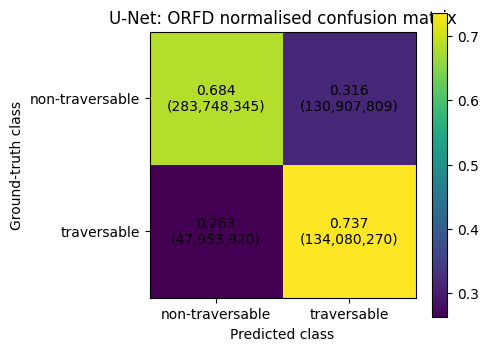

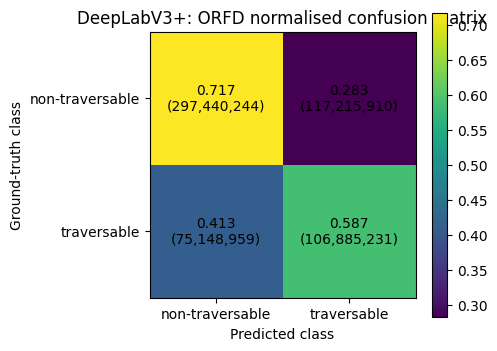

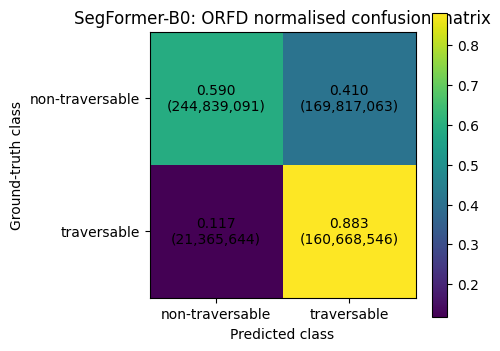

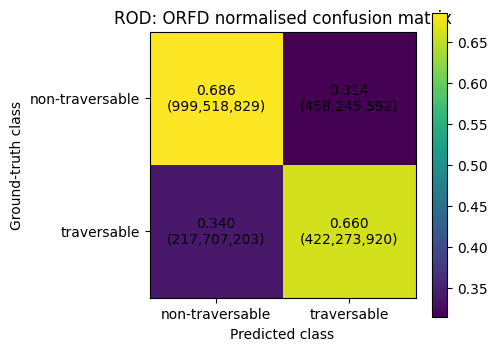

In [14]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, title):
    cm = cm.numpy().astype(np.float64)

    row_sums = cm.sum(
        axis=1,
        keepdims=True,
    )

    normalized = np.divide(
        cm,
        row_sums,
        out=np.zeros_like(cm),
        where=row_sums != 0,
    )

    fig, ax = plt.subplots(
        figsize=(5, 4)
    )

    image = ax.imshow(normalized)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels([
        "non-traversable",
        "traversable",
    ])

    ax.set_yticklabels([
        "non-traversable",
        "traversable",
    ])

    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Ground-truth class")
    ax.set_title(title)

    for row in range(2):
        for column in range(2):
            ax.text(
                column,
                row,
                f"{normalized[row, column]:.3f}\n"
                f"({int(cm[row, column]):,})",
                ha="center",
                va="center",
            )

    fig.colorbar(image, ax=ax)
    plt.tight_layout()
    plt.show()

for model_name, cm in confusion_matrices.items():
    plot_confusion_matrix(
        cm,
        f"{model_name}: ORFD normalised confusion matrix",
    )

## 12. Top-5 and bottom-5 visualisations

In [15]:
from matplotlib.colors import ListedColormap


@torch.inference_mode()
def predict_single_image(
    model_name,
    model,
    image_path,
):
    config = MODEL_CONFIGS[
        model_name
    ]

    image = Image.open(
        image_path
    ).convert("RGB")

    # ----------------------------------------------------------
    # ROD
    # ----------------------------------------------------------
    if model_name == "ROD":
        image_np = np.array(
            image
        )

        rgb = (
            image_np.astype(
                np.float32
            )
            / 255.0
        )

        padded_image, meta = (
            rod_resize_pad(
                image_np,
                size=512,
            )
        )

        tensor = (
            rod_normalize_image(
                padded_image
            )
            .unsqueeze(0)
            .to(DEVICE)
            .float()
        )

        output = model(
            tensor
        )

        logits = extract_logits(
            model_name,
            output,
            target_size=(512, 512),
        )

        padded_prediction = (
            torch.argmax(
                logits,
                dim=1,
            )[0]
            .cpu()
            .numpy()
            .astype(np.uint8)
        )

        prediction = (
            restore_rod_prediction(
                padded_prediction,
                meta,
            )
        )

        return (
            rgb,
            prediction,
        )

    # ----------------------------------------------------------
    # Baseline models
    # ----------------------------------------------------------
    resized = TF.resize(
        image,
        config["input_size"],
        interpolation=InterpolationMode.BILINEAR,
        antialias=True,
    )

    tensor = TF.to_tensor(
        resized
    )

    if (
        config["normalization"]
        == "imagenet"
    ):
        tensor = TF.normalize(
            tensor,
            IMAGENET_MEAN,
            IMAGENET_STD,
        )

    tensor = (
        tensor.unsqueeze(0)
        .to(DEVICE)
    )

    output = model(
        tensor
    )

    logits = extract_logits(
        model_name,
        output,
        target_size=config[
            "input_size"
        ],
    )

    prediction = (
        torch.argmax(
            logits,
            dim=1,
        )[0]
        .cpu()
        .numpy()
        .astype(np.uint8)
    )

    rgb = (
        np.array(
            resized
        ).astype(
            np.float32
        )
        / 255.0
    )

    return (
        rgb,
        prediction,
    )


def load_mask_at_model_size(
    model_name,
    mask_path,
):
    binary_mask = (
        load_orfd_binary_mask(
            mask_path
        )
    )

    if model_name == "ROD":
        return (
            binary_mask.astype(
                np.uint8
            )
        )

    mask = Image.fromarray(
        binary_mask
    )

    mask = TF.resize(
        mask,
        MODEL_CONFIGS[
            model_name
        ]["input_size"],
        interpolation=InterpolationMode.NEAREST,
    )

    return np.array(
        mask,
        dtype=np.uint8,
    )


def binary_mask_for_display(
    mask
):
    """
    ORFD colour convention:
      black = non-traversable
      white = traversable
      gray  = ignore (unreachable)
    """

    vis = np.zeros_like(
        mask,
        dtype=np.uint8,
    )

    vis[
        mask
        == NON_TRAVERSABLE_CLASS
    ] = 0

    vis[
        mask
        == TRAVERSABLE_CLASS
    ] = 1

    vis[
        mask
        == IGNORE_INDEX
    ] = 2

    return vis


def make_traversable_overlay(
    rgb,
    prediction,
    target,
    ignore_index=255,
    alpha=0.40,
):
    overlay = rgb.copy()

    valid_traversable = (
        (
            prediction
            == TRAVERSABLE_CLASS
        )
        & (
            target
            != ignore_index
        )
    )

    green = np.zeros_like(
        rgb
    )
    green[..., 1] = 1.0

    overlay[
        valid_traversable
    ] = (
        (1.0 - alpha)
        * rgb[
            valid_traversable
        ]
        + alpha
        * green[
            valid_traversable
        ]
    )

    return np.clip(
        overlay,
        0,
        1,
    )


def make_error_rgb(
    prediction,
    target,
    ignore_index=255,
):
    """
    red   = false traversable
    blue  = false non-traversable
    black = correct or ignored
    """

    error_rgb = np.zeros(
        (*target.shape, 3),
        dtype=np.uint8,
    )

    valid = (
        target
        != ignore_index
    )

    false_traversable = (
        valid
        & (
            target
            == NON_TRAVERSABLE_CLASS
        )
        & (
            prediction
            == TRAVERSABLE_CLASS
        )
    )

    false_non_traversable = (
        valid
        & (
            target
            == TRAVERSABLE_CLASS
        )
        & (
            prediction
            == NON_TRAVERSABLE_CLASS
        )
    )

    error_rgb[
        false_traversable
    ] = [255, 0, 0]

    error_rgb[
        false_non_traversable
    ] = [0, 0, 255]

    return error_rgb


def visualise_case(
    model_name,
    model,
    image_path,
    mask_path,
    metrics,
    group_name,
    rank,
    save_root=None,
):
    rgb, prediction = (
        predict_single_image(
            model_name,
            model,
            image_path,
        )
    )

    target = (
        load_mask_at_model_size(
            model_name,
            mask_path,
        )
    )

    mask_cmap = ListedColormap(
        [
            "black",
            "white",
            "gray",
        ]
    )

    gt_vis = (
        binary_mask_for_display(
            target
        )
    )

    pred_vis = (
        binary_mask_for_display(
            prediction
        )
    )

    pred_vis[
        target
        == IGNORE_INDEX
    ] = 2

    overlay = (
        make_traversable_overlay(
            rgb=rgb,
            prediction=prediction,
            target=target,
            ignore_index=IGNORE_INDEX,
            alpha=0.40,
        )
    )

    error_map = (
        make_error_rgb(
            prediction=prediction,
            target=target,
            ignore_index=IGNORE_INDEX,
        )
    )

    figure, axes = (
        plt.subplots(
            1,
            5,
            figsize=(23, 5),
        )
    )

    axes[0].imshow(
        rgb
    )
    axes[0].set_title(
        "RGB"
    )

    axes[1].imshow(
        gt_vis,
        cmap=mask_cmap,
        vmin=0,
        vmax=2,
    )
    axes[1].set_title(
        "GT traversable"
    )

    axes[2].imshow(
        pred_vis,
        cmap=mask_cmap,
        vmin=0,
        vmax=2,
    )
    axes[2].set_title(
        f"{model_name} prediction"
    )

    axes[3].imshow(
        overlay
    )
    axes[3].set_title(
        "Prediction overlay"
    )

    axes[4].imshow(
        error_map
    )
    axes[4].set_title(
        "Errors\n"
        "red=false traversable\n"
        "blue=false non-traversable"
    )

    for axis in axes:
        axis.axis(
            "off"
        )

    figure.suptitle(
        f"{Path(image_path).name}\n"
        f"{group_name} #{rank} | "
        f"mIoU={metrics['miou']:.4f} | "
        f"NT IoU={metrics['non_traversable_iou']:.4f} | "
        f"T IoU={metrics['traversable_iou']:.4f}",
        fontsize=11,
    )

    plt.tight_layout(
        rect=[
            0,
            0,
            1,
            0.90,
        ]
    )

    if save_root is not None:
        safe_model = (
            model_name.lower()
            .replace(
                "+",
                "plus",
            )
            .replace(
                "-",
                "_",
            )
            .replace(
                " ",
                "_",
            )
        )

        group_dir = (
            Path(
                save_root
            )
            / safe_model
            / group_name.lower()
            .replace(
                " ",
                "_",
            )
            .replace(
                "-",
                "",
            )
        )

        group_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        figure.savefig(
            group_dir
            / (
                f"{rank:02d}_"
                f"{Path(image_path).stem}.png"
            ),
            dpi=180,
            bbox_inches="tight",
        )

    plt.show()
    plt.close(
        figure
    )


RANKED_VIS_DIR = RESULTS_ROOT / "ranked_cases"
RANKED_VIS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_DISPLAY_ORDER = [
    "U-Net",
    "DeepLabV3+",
    "SegFormer-B0",
    "ROD",
]

print("\nModels available for ranked visualisation:")
print("loaded_models:", list(loaded_models.keys()))
print("per_image_results:", list(per_image_results.keys()))

for model_name in MODEL_DISPLAY_ORDER:
    if model_name not in loaded_models:
        raise KeyError(
            f"{model_name} is missing from loaded_models. "
            "Re-run the evaluation cell first."
        )
    if model_name not in per_image_results:
        raise KeyError(
            f"{model_name} is missing from per_image_results. "
            "Re-run the evaluation cell first."
        )

    model = loaded_models[model_name]
    dataframe = per_image_results[model_name].copy()
    valid_df = dataframe.dropna(subset=["miou"]).copy()

    top_five = valid_df.sort_values("miou", ascending=False).head(5)
    bottom_five = valid_df.sort_values("miou", ascending=True).head(5)

    safe_model = (
        model_name.lower()
        .replace("+", "plus")
        .replace("-", "_")
        .replace(" ", "_")
    )

    top_five.to_csv(
        RESULTS_ROOT / f"{safe_model}_top5.csv",
        index=False,
    )
    bottom_five.to_csv(
        RESULTS_ROOT / f"{safe_model}_bottom5.csv",
        index=False,
    )

    print("\n" + "=" * 90)
    print(f"{model_name}: TOP-5 BEST CASES")
    print("=" * 90)
    display(
        top_five[
            [
                "sequence",
                "stem",
                "miou",
                "non_traversable_iou",
                "traversable_iou",
                "image_path",
            ]
        ].reset_index(drop=True)
    )

    for rank, (_, row) in enumerate(top_five.iterrows(), start=1):
        visualise_case(
            model_name=model_name,
            model=model,
            image_path=row["image_path"],
            mask_path=row["mask_path"],
            metrics=row,
            group_name="Top-5 Best",
            rank=rank,
            save_root=RANKED_VIS_DIR,
        )

    print("\n" + "=" * 90)
    print(f"{model_name}: BOTTOM-5 WORST CASES")
    print("=" * 90)
    display(
        bottom_five[
            [
                "sequence",
                "stem",
                "miou",
                "non_traversable_iou",
                "traversable_iou",
                "image_path",
            ]
        ].reset_index(drop=True)
    )

    for rank, (_, row) in enumerate(bottom_five.iterrows(), start=1):
        visualise_case(
            model_name=model_name,
            model=model,
            image_path=row["image_path"],
            mask_path=row["mask_path"],
            metrics=row,
            group_name="Bottom-5 Worst",
            rank=rank,
            save_root=RANKED_VIS_DIR,
        )

print("\nFinished Top-5 / Bottom-5 visualisation for all four models, including ROD.")

Output hidden; open in https://colab.research.google.com to view.

## 13. Select representative RUGD → ORFD cross-dataset cases

The qualitative examples are selected with **model-agnostic criteria** so that
the figure does not assume in advance that any particular architecture is best.

The three final cases are:

1. **Successful transfer** — high average mIoU with low disagreement across all four models.
2. **Non-traversable challenge** — traversable IoU remains relatively strong while non-traversable IoU is substantially lower.
3. **Model disagreement** — the four models show the largest spread in per-image mIoU.

The third criterion is defined as

`max(per-image mIoU across models) - min(per-image mIoU across models)`

and therefore does not condition the selection on ROD or any other model.


In [16]:
# ================================================================
# 13. Merge per-image metrics across all four models
# ================================================================

MODEL_DISPLAY_ORDER = [
    "U-Net",
    "DeepLabV3+",
    "SegFormer-B0",
    "ROD",
]

METRIC_COLUMNS = [
    "miou",
    "non_traversable_iou",
    "traversable_iou",
]

combined = None

for model_name in MODEL_DISPLAY_ORDER:

    dataframe = per_image_results[
        model_name
    ].copy()

    subset = dataframe[
        [
            "sequence",
            "stem",
            "image_path",
            "mask_path",
        ] + METRIC_COLUMNS
    ].copy()

    subset = subset.rename(
        columns={
            metric: f"{model_name}__{metric}"
            for metric in METRIC_COLUMNS
        }
    )

    if combined is None:
        combined = subset
    else:
        combined = combined.merge(
            subset,
            on=[
                "sequence",
                "stem",
                "image_path",
                "mask_path",
            ],
            how="inner",
        )


miou_columns = [
    f"{name}__miou"
    for name in MODEL_DISPLAY_ORDER
]

non_traversable_columns = [
    f"{name}__non_traversable_iou"
    for name in MODEL_DISPLAY_ORDER
]

traversable_columns = [
    f"{name}__traversable_iou"
    for name in MODEL_DISPLAY_ORDER
]


# ------------------------------------------------
# Aggregate cross-model behaviour
# ------------------------------------------------

combined["average_miou"] = combined[
    miou_columns
].mean(
    axis=1,
    skipna=True,
)

combined["std_miou"] = combined[
    miou_columns
].std(
    axis=1,
    skipna=True,
)

combined["average_non_traversable_iou"] = combined[
    non_traversable_columns
].mean(
    axis=1,
    skipna=True,
)

combined["average_traversable_iou"] = combined[
    traversable_columns
].mean(
    axis=1,
    skipna=True,
)

combined["traversable_minus_non_traversable"] = (
    combined["average_traversable_iou"]
    - combined["average_non_traversable_iou"]
)


# ------------------------------------------------
# Model-agnostic disagreement metrics
# ------------------------------------------------

combined["best_model_miou"] = combined[
    miou_columns
].max(
    axis=1,
    skipna=True,
)

combined["worst_model_miou"] = combined[
    miou_columns
].min(
    axis=1,
    skipna=True,
)

combined["model_disagreement"] = (
    combined["best_model_miou"]
    - combined["worst_model_miou"]
)


required_columns = [
    "average_miou",
    "std_miou",
    "average_non_traversable_iou",
    "average_traversable_iou",
    "traversable_minus_non_traversable",
    "best_model_miou",
    "worst_model_miou",
    "model_disagreement",
]

selection_df = combined.dropna(
    subset=required_columns
).copy()


print(
    "Images available for representative selection:",
    len(selection_df),
)

display(
    selection_df[
        [
            "sequence",
            "stem",
            "average_miou",
            "std_miou",
            "average_non_traversable_iou",
            "average_traversable_iou",
            "model_disagreement",
        ]
    ].head()
)


Images available for representative selection: 2555


,sequence,stem,average_miou,std_miou,average_non_traversable_iou,average_traversable_iou,model_disagreement
0,x2021_0223_1756,1620322699201,0.543539,0.067551,0.633856,0.453222,0.152834
1,x2021_0223_1756,1620322699293,0.550254,0.045445,0.637096,0.463413,0.110722
2,x2021_0223_1756,1620322699481,0.540597,0.053380,0.627848,0.453346,0.119659
3,x2021_0223_1756,1620322699599,0.551938,0.048090,0.638584,0.465292,0.095948
4,x2021_0223_1756,1620322699679,0.557886,0.042628,0.644868,0.470905,0.092119


## 14. Rank candidate images

Ten candidates are retained for each category. This allows a final visual check
for scene diversity without changing the underlying metric-based selection rule.


In [17]:
# ================================================================
# 14. Representative-case ranking
# ================================================================

REPRESENTATIVE_DIR = (
    RESULTS_ROOT
    / "representative_cases_3x6_model_agnostic"
)

REPRESENTATIVE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CANDIDATES_PER_CATEGORY = 10


# ================================================================
# 1. Successful transfer
#
# Top 20% by mean mIoU, then prefer low inter-model disagreement.
# ================================================================

successful_pool = selection_df[
    selection_df["average_miou"]
    >= selection_df["average_miou"].quantile(0.80)
].copy()

successful_pool["selection_score"] = (
    successful_pool["average_miou"]
    - 0.50 * successful_pool["std_miou"]
)

successful_candidates = (
    successful_pool
    .sort_values(
        "selection_score",
        ascending=False,
    )
    .head(CANDIDATES_PER_CATEGORY)
    .copy()
)


# ================================================================
# 2. Non-traversable challenge
#
# Model-agnostic class-specific difficulty:
# traversable performance remains reasonable, while
# non-traversable performance is substantially weaker.
# ================================================================

traversable_threshold = selection_df[
    "average_traversable_iou"
].median()

nt_pool = selection_df[
    selection_df["average_traversable_iou"]
    >= traversable_threshold
].copy()

nt_pool["selection_score"] = (
    nt_pool["traversable_minus_non_traversable"]
    + 0.25 * (
        1.0
        - nt_pool["average_non_traversable_iou"]
    )
)

non_traversable_candidates = (
    nt_pool
    .sort_values(
        "selection_score",
        ascending=False,
    )
    .head(CANDIDATES_PER_CATEGORY)
    .copy()
)


# ================================================================
# 3. Model disagreement
#
# Completely model-agnostic:
# select images with the largest mIoU range across all four models.
# ================================================================

disagreement_candidates = (
    selection_df
    .sort_values(
        "model_disagreement",
        ascending=False,
    )
    .head(CANDIDATES_PER_CATEGORY)
    .copy()
)


candidate_tables = {
    "01_successful_transfer": successful_candidates,
    "02_non_traversable_challenge": non_traversable_candidates,
    "03_model_disagreement": disagreement_candidates,
}

CASE_LABELS = {
    "01_successful_transfer": "Successful transfer",
    "02_non_traversable_challenge": "Non-traversable challenge",
    "03_model_disagreement": "Model disagreement",
}


# ------------------------------------------------
# Save candidate tables
# ------------------------------------------------

for category, candidate_df in candidate_tables.items():

    path = (
        REPRESENTATIVE_DIR
        / f"{category}_top{CANDIDATES_PER_CATEGORY}_candidates.csv"
    )

    candidate_df.to_csv(
        path,
        index=False,
    )


print("=== SUCCESSFUL TRANSFER ===")
display(
    successful_candidates[
        [
            "sequence",
            "stem",
            "average_miou",
            "std_miou",
            "average_non_traversable_iou",
            "average_traversable_iou",
        ]
    ]
)

print("=== NON-TRAVERSABLE CHALLENGE ===")
display(
    non_traversable_candidates[
        [
            "sequence",
            "stem",
            "average_miou",
            "average_non_traversable_iou",
            "average_traversable_iou",
            "traversable_minus_non_traversable",
        ]
    ]
)

print("=== MODEL DISAGREEMENT ===")
display(
    disagreement_candidates[
        [
            "sequence",
            "stem",
            "average_miou",
            "model_disagreement",
            "best_model_miou",
            "worst_model_miou",
            "U-Net__miou",
            "DeepLabV3+__miou",
            "SegFormer-B0__miou",
            "ROD__miou",
        ]
    ]
)


=== SUCCESSFUL TRANSFER ===


,sequence,stem,average_miou,std_miou,average_non_traversable_iou,average_traversable_iou
654,y0602_1330,1623175283847,0.804793,0.066020,0.851223,0.758362
666,y0602_1330,1623175289187,0.810240,0.093952,0.852072,0.768408
629,y0602_1330,1623175278285,0.787649,0.064009,0.836962,0.738336
665,y0602_1330,1623175288992,0.799961,0.088884,0.843466,0.756457
630,y0602_1330,1623175278698,0.771405,0.033787,0.823657,0.719153
653,y0602_1330,1623175283269,0.780309,0.055232,0.830183,0.730434
667,y0602_1330,1623175289339,0.794444,0.085630,0.840212,0.748675
655,y0602_1330,1623175284361,0.780948,0.062632,0.831493,0.730404
664,y0602_1330,1623175288630,0.800794,0.102584,0.844268,0.757321
631,y0602_1330,1623175278926,0.793200,0.094463,0.838951,0.747449


=== NON-TRAVERSABLE CHALLENGE ===


,sequence,stem,average_miou,average_non_traversable_iou,average_traversable_iou,traversable_minus_non_traversable
1619,y0613_1242,1623721548395,0.516779,0.457183,0.576376,0.119193
1620,y0613_1242,1623721548494,0.519704,0.460183,0.579226,0.119043
1618,y0613_1242,1623721548293,0.518124,0.459726,0.576521,0.116795
1614,y0613_1242,1623721547795,0.521139,0.462482,0.579795,0.117312
1617,y0613_1242,1623721548194,0.517978,0.461170,0.574786,0.113616
1616,y0613_1242,1623721548099,0.519643,0.463478,0.575809,0.112331
1615,y0613_1242,1623721547999,0.526978,0.470007,0.583949,0.113942
1621,y0613_1242,1623721548798,0.504117,0.451494,0.556739,0.105245
1613,y0613_1242,1623721547696,0.522703,0.468819,0.576587,0.107768
1624,y0613_1242,1623721549102,0.491088,0.440966,0.541211,0.100245


=== MODEL DISAGREEMENT ===


,sequence,stem,average_miou,model_disagreement,best_model_miou,worst_model_miou,U-Net__miou,DeepLabV3+__miou,SegFormer-B0__miou,ROD__miou
2086,y2021_0228_1802,1620330271537,0.451959,0.631167,0.891170,0.260003,0.260003,0.315315,0.341346,0.891170
2085,y2021_0228_1802,1620330271447,0.471789,0.629737,0.911386,0.281649,0.281649,0.310519,0.383601,0.911386
2084,y2021_0228_1802,1620330271253,0.490972,0.622630,0.870144,0.247514,0.247514,0.302478,0.543751,0.870144
2022,y2021_0228_1802,1620330263047,0.423078,0.618601,0.794683,0.176081,0.176081,0.313599,0.407948,0.794683
2460,y2021_0228_1802,1620330316346,0.556924,0.615695,0.920785,0.305090,0.538198,0.305090,0.920785,0.463620
2024,y2021_0228_1802,1620330263340,0.420452,0.607970,0.798906,0.190936,0.190936,0.259519,0.432446,0.798906
2088,y2021_0228_1802,1620330271761,0.456216,0.601920,0.855294,0.253375,0.253375,0.341242,0.374955,0.855294
2304,y2021_0228_1802,1620330297168,0.483340,0.600925,0.856497,0.255572,0.495373,0.325919,0.856497,0.255572
1892,y2021_0228_1802,1620330246737,0.472340,0.599137,0.863074,0.263937,0.863074,0.263937,0.353312,0.409036
2293,y2021_0228_1802,1620330295845,0.454408,0.592589,0.862958,0.270369,0.386512,0.297794,0.862958,0.270369


## 15. Preview top-10 RGB candidates and choose the final three

The preview is used only to avoid visually repetitive frames. The highest-ranked
candidate is used by default. If a different candidate is more visually
representative, change its rank in `MANUAL_SELECTION`.


In [18]:
# ================================================================
# 15. Candidate preview and optional manual override
# ================================================================

MANUAL_SELECTION = {
    "01_successful_transfer": 1,
    "02_non_traversable_challenge": 1,
    "03_model_disagreement": 1,
}


def preview_rgb_candidates(
    category,
    candidate_df,
    max_images=10,
):

    n = min(
        max_images,
        len(candidate_df),
    )

    if n == 0:
        print(
            f"No candidates for {category}"
        )
        return

    fig, axes = plt.subplots(
        2,
        5,
        figsize=(18, 7),
    )

    axes = np.array(
        axes
    ).reshape(-1)

    for i in range(10):

        ax = axes[i]

        if i >= n:
            ax.axis("off")
            continue

        row = candidate_df.iloc[i]

        rgb = np.array(
            Image.open(
                row["image_path"]
            ).convert("RGB")
        )

        ax.imshow(rgb)

        # Third category gets a disagreement-specific title.
        if category == "03_model_disagreement":

            ax.set_title(
                f"#{i + 1} | disagreement={row['model_disagreement']:.3f}\n"
                f"U={row['U-Net__miou']:.3f}, "
                f"D={row['DeepLabV3+__miou']:.3f}, "
                f"S={row['SegFormer-B0__miou']:.3f}, "
                f"R={row['ROD__miou']:.3f}",
                fontsize=8,
            )

        else:

            ax.set_title(
                f"#{i + 1} | avg mIoU={row['average_miou']:.3f}\n"
                f"NT={row['average_non_traversable_iou']:.3f}, "
                f"T={row['average_traversable_iou']:.3f}",
                fontsize=9,
            )

        ax.axis("off")

    fig.suptitle(
        CASE_LABELS.get(
            category,
            category,
        ),
        fontsize=14,
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.95]
    )

    plt.show()
    plt.close(fig)


for category, candidate_df in candidate_tables.items():

    print(
        "\n",
        "=" * 20,
        category.upper(),
        "=" * 20,
    )

    preview_rgb_candidates(
        category,
        candidate_df,
        max_images=CANDIDATES_PER_CATEGORY,
    )


# ================================================================
# Apply manual ranks and avoid exact duplicate frames
# ================================================================

final_rows = []
used_image_paths = set()

for category in [
    "01_successful_transfer",
    "02_non_traversable_challenge",
    "03_model_disagreement",
]:

    candidate_df = candidate_tables[
        category
    ]

    requested_rank = int(
        MANUAL_SELECTION[
            category
        ]
    )

    if not 1 <= requested_rank <= len(candidate_df):
        raise ValueError(
            f"{category}: rank {requested_rank} is outside "
            f"1..{len(candidate_df)}"
        )

    ordered_positions = (
        list(
            range(
                requested_rank - 1,
                len(candidate_df),
            )
        )
        + list(
            range(
                0,
                requested_rank - 1,
            )
        )
    )

    chosen = None

    for position in ordered_positions:

        candidate = (
            candidate_df
            .iloc[position]
            .copy()
        )

        image_path = str(
            candidate["image_path"]
        )

        if image_path not in used_image_paths:
            chosen = candidate
            used_image_paths.add(
                image_path
            )
            break

    if chosen is None:
        raise RuntimeError(
            f"No unused candidate remained for {category}"
        )

    chosen["case_key"] = category
    chosen["case_label"] = CASE_LABELS[
        category
    ]

    final_rows.append(
        chosen
    )


final_cases = pd.DataFrame(
    final_rows
).reset_index(
    drop=True
)

FINAL_CASES_CSV = (
    REPRESENTATIVE_DIR
    / "final_representative_cases.csv"
)

final_cases.to_csv(
    FINAL_CASES_CSV,
    index=False,
)

display(
    final_cases[
        [
            "case_label",
            "sequence",
            "stem",
            "average_miou",
            "average_non_traversable_iou",
            "average_traversable_iou",
            "model_disagreement",
        ]
    ]
)

print(
    "Saved:",
    FINAL_CASES_CSV,
)


Output hidden; open in https://colab.research.google.com to view.

## 16. Generate the final 3 × 6 RUGD → ORFD error-overlay figure

The display style is identical to the latest in-domain figure:

`Input | Ground Truth | U-Net | DeepLabV3+ | SegFormer-B0 | ROD`

For ORFD:

- **black** = correct non-traversable
- **white** = correct traversable
- **red** = false traversable (`GT non-traversable → predicted traversable`)
- **blue** = false non-traversable (`GT traversable → predicted non-traversable`)
- **gray** = ignore / unreachable

The third row is labelled **Model disagreement** and is selected without
conditioning on any particular model.


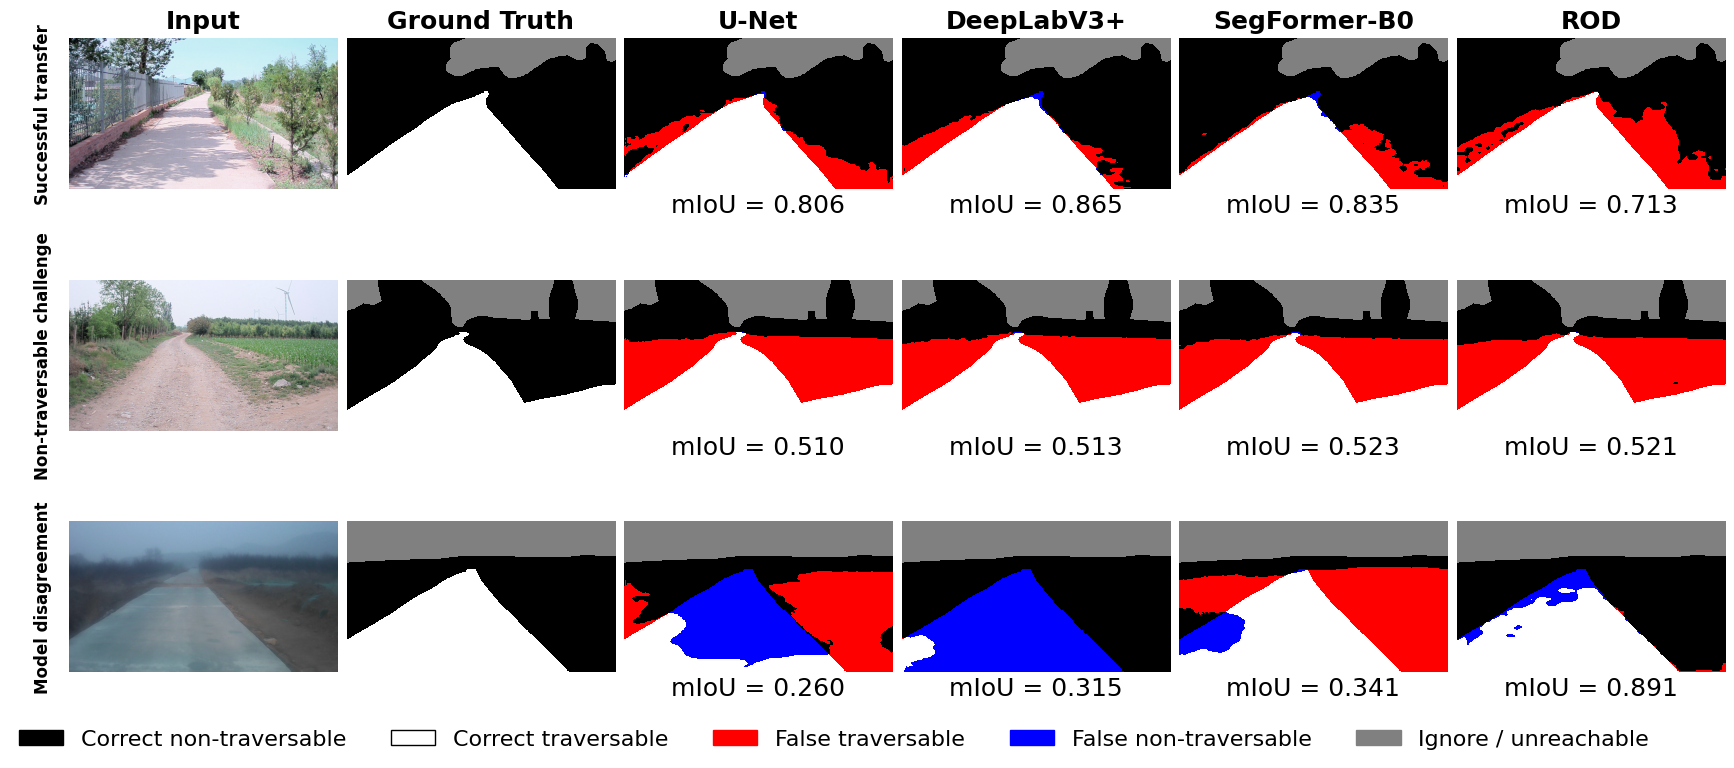

Saved final RUGD -> ORFD figure:
PNG: /content/drive/MyDrive/IRP/03_cross_dataset/rugd_to_orfd/representative_cases_3x6_model_agnostic/rugd_to_orfd_model_agnostic_3x6_error_overlay.png
PDF: /content/drive/MyDrive/IRP/03_cross_dataset/rugd_to_orfd/representative_cases_3x6_model_agnostic/rugd_to_orfd_model_agnostic_3x6_error_overlay.pdf


In [19]:
# ================================================================
# 16. Final 3 x 6 dissertation figure with error overlay
# ================================================================

from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch


def resize_prediction_to_original(
    prediction,
    original_h,
    original_w,
):

    if prediction.shape == (
        original_h,
        original_w,
    ):
        return prediction.astype(
            np.uint8
        )

    return np.array(
        Image.fromarray(
            prediction.astype(
                np.uint8
            )
        ).resize(
            (
                original_w,
                original_h,
            ),
            resample=Image.Resampling.NEAREST,
        ),
        dtype=np.uint8,
    )


def make_orfd_error_map(
    prediction,
    target,
    ignore_index=IGNORE_INDEX,
):
    """
    Encoded display values:

        0 = correct non-traversable
        1 = correct traversable
        2 = false traversable
            GT non-traversable -> predicted traversable
        3 = false non-traversable
            GT traversable -> predicted non-traversable
        4 = ignore / unreachable
    """

    error_map = np.full(
        target.shape,
        4,
        dtype=np.uint8,
    )

    valid = (
        target
        != ignore_index
    )

    # Correct non-traversable
    error_map[
        valid
        & (
            target
            == NON_TRAVERSABLE_CLASS
        )
        & (
            prediction
            == NON_TRAVERSABLE_CLASS
        )
    ] = 0

    # Correct traversable
    error_map[
        valid
        & (
            target
            == TRAVERSABLE_CLASS
        )
        & (
            prediction
            == TRAVERSABLE_CLASS
        )
    ] = 1

    # False traversable
    error_map[
        valid
        & (
            target
            == NON_TRAVERSABLE_CLASS
        )
        & (
            prediction
            == TRAVERSABLE_CLASS
        )
    ] = 2

    # False non-traversable
    error_map[
        valid
        & (
            target
            == TRAVERSABLE_CLASS
        )
        & (
            prediction
            == NON_TRAVERSABLE_CLASS
        )
    ] = 3

    return error_map


def make_orfd_gt_display(
    target,
    ignore_index=IGNORE_INDEX,
):
    """
    Display encoding:

        0 = non-traversable
        1 = traversable
        2 = ignore / unreachable
    """

    gt_vis = np.zeros_like(
        target,
        dtype=np.uint8,
    )

    gt_vis[
        target
        == NON_TRAVERSABLE_CLASS
    ] = 0

    gt_vis[
        target
        == TRAVERSABLE_CLASS
    ] = 1

    gt_vis[
        target
        == ignore_index
    ] = 2

    return gt_vis


@torch.inference_mode()
def make_orfd_representative_figure_3x6(
    final_cases,
    save_dir,
    dpi=300,
):

    model_order = [
        "U-Net",
        "DeepLabV3+",
        "SegFormer-B0",
        "ROD",
    ]

    column_titles = [
        "Input",
        "Ground Truth",
        "U-Net",
        "DeepLabV3+",
        "SegFormer-B0",
        "ROD",
    ]

    error_cmap = ListedColormap(
        [
            "black",
            "white",
            "red",
            "blue",
            "gray",
        ]
    )

    gt_cmap = ListedColormap(
        [
            "black",
            "white",
            "gray",
        ]
    )

    n_rows = len(
        final_cases
    )

    n_cols = len(
        column_titles
    )

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(18, 8.0),
        squeeze=False,
    )

    for row_index, (_, case) in enumerate(
        final_cases.iterrows()
    ):

        image_path = case[
            "image_path"
        ]

        mask_path = case[
            "mask_path"
        ]

        # --------------------------------------------------------
        # Original RGB and ORFD target
        # --------------------------------------------------------

        original_rgb = np.array(
            Image.open(
                image_path
            ).convert("RGB")
        )

        original_h, original_w = (
            original_rgb.shape[:2]
        )

        target = (
            load_orfd_binary_mask(
                mask_path
            )
            .astype(
                np.uint8
            )
        )

        if target.shape != (
            original_h,
            original_w,
        ):

            target = np.array(
                Image.fromarray(
                    target
                ).resize(
                    (
                        original_w,
                        original_h,
                    ),
                    resample=Image.Resampling.NEAREST,
                ),
                dtype=np.uint8,
            )

        # --------------------------------------------------------
        # Input
        # --------------------------------------------------------

        axes[
            row_index,
            0,
        ].imshow(
            original_rgb
        )

        axes[
            row_index,
            0,
        ].set_xlabel("")

        # --------------------------------------------------------
        # Ground truth
        # --------------------------------------------------------

        gt_vis = make_orfd_gt_display(
            target
        )

        axes[
            row_index,
            1,
        ].imshow(
            gt_vis,
            cmap=gt_cmap,
            vmin=0,
            vmax=2,
            interpolation="nearest",
        )

        # --------------------------------------------------------
        # Four model predictions + errors
        # --------------------------------------------------------

        for model_offset, model_name in enumerate(
            model_order,
            start=2,
        ):

            _, prediction = (
                predict_single_image(
                    model_name=model_name,
                    model=loaded_models[
                        model_name
                    ],
                    image_path=image_path,
                )
            )

            prediction_original = (
                resize_prediction_to_original(
                    prediction,
                    original_h,
                    original_w,
                )
            )

            error_map = make_orfd_error_map(
                prediction=prediction_original,
                target=target,
                ignore_index=IGNORE_INDEX,
            )

            axes[
                row_index,
                model_offset,
            ].imshow(
                error_map,
                cmap=error_cmap,
                vmin=0,
                vmax=4,
                interpolation="nearest",
            )

            model_miou = case[
                f"{model_name}__miou"
            ]

            axes[
                row_index,
                model_offset,
            ].set_xlabel(
                f"mIoU = {model_miou:.3f}",
                fontsize=18,
                labelpad=3,
            )

        # --------------------------------------------------------
        # Row label
        # --------------------------------------------------------

        axes[
            row_index,
            0,
        ].set_ylabel(
            case[
                "case_label"
            ],
            fontsize=12,
            rotation=90,
            labelpad=12,
            fontweight="bold",
        )

        # --------------------------------------------------------
        # Clean axes
        # --------------------------------------------------------

        for col_index in range(
            n_cols
        ):

            axes[
                row_index,
                col_index,
            ].set_xticks([])

            axes[
                row_index,
                col_index,
            ].set_yticks([])

            for spine in axes[
                row_index,
                col_index,
            ].spines.values():

                spine.set_visible(
                    False
                )

    # ------------------------------------------------------------
    # Column titles
    # ------------------------------------------------------------

    for col_index, title in enumerate(
        column_titles
    ):

        axes[
            0,
            col_index,
        ].set_title(
            title,
            fontsize=18,
            fontweight="bold",
            pad=7,
        )

    # ------------------------------------------------------------
    # Legend
    # ------------------------------------------------------------

    legend_elements = [
        Patch(
            facecolor="black",
            edgecolor="black",
            label="Correct non-traversable",
        ),
        Patch(
            facecolor="white",
            edgecolor="black",
            label="Correct traversable",
        ),
        Patch(
            facecolor="red",
            edgecolor="red",
            label="False traversable",
        ),
        Patch(
            facecolor="blue",
            edgecolor="blue",
            label="False non-traversable",
        ),
        Patch(
            facecolor="gray",
            edgecolor="gray",
            label="Ignore / unreachable",
        ),
    ]

    fig.legend(
        handles=legend_elements,
        loc="lower center",
        ncol=5,
        fontsize=16,
        frameon=False,
        bbox_to_anchor=(
            0.5,
            0.005,
        ),
    )

    # ------------------------------------------------------------
    # Layout
    # ------------------------------------------------------------

    fig.subplots_adjust(
        left=0.075,
        right=0.995,
        top=0.955,
        bottom=0.09,
        wspace=0.035,
        hspace=0.16,
    )

    # ------------------------------------------------------------
    # Save
    # ------------------------------------------------------------

    save_dir = Path(
        save_dir
    )

    save_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    png_path = (
        save_dir
        / "rugd_to_orfd_model_agnostic_3x6_error_overlay.png"
    )

    pdf_path = (
        save_dir
        / "rugd_to_orfd_model_agnostic_3x6_error_overlay.pdf"
    )

    fig.savefig(
        png_path,
        dpi=dpi,
        bbox_inches="tight",
        pad_inches=0.03,
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight",
        pad_inches=0.03,
    )

    plt.show()
    plt.close(
        fig
    )

    return (
        png_path,
        pdf_path,
    )


figure_png, figure_pdf = (
    make_orfd_representative_figure_3x6(
        final_cases=final_cases,
        save_dir=REPRESENTATIVE_DIR,
        dpi=300,
    )
)

print(
    "Saved final RUGD -> ORFD figure:"
)

print(
    "PNG:",
    figure_png,
)

print(
    "PDF:",
    figure_pdf,
)


## 17. Export selected-case summary

The summary records the exact images and per-model mIoU values used in the
final figure. The third row also includes the model-disagreement score.


In [20]:
# ================================================================
# 17. Selected representative-case summary
# ================================================================

summary_columns = [
    "case_label",
    "sequence",
    "stem",
    "average_miou",
    "average_non_traversable_iou",
    "average_traversable_iou",
    "model_disagreement",
    "best_model_miou",
    "worst_model_miou",
    "U-Net__miou",
    "DeepLabV3+__miou",
    "SegFormer-B0__miou",
    "ROD__miou",
]

selected_summary_df = final_cases[
    summary_columns
].copy()

SELECTED_SUMMARY_CSV = (
    REPRESENTATIVE_DIR
    / "selected_representative_cases_summary.csv"
)

selected_summary_df.to_csv(
    SELECTED_SUMMARY_CSV,
    index=False,
)

display(
    selected_summary_df
)

print(
    "Saved:",
    SELECTED_SUMMARY_CSV,
)

print(
    "\nFinal dissertation figure:"
)

print(
    REPRESENTATIVE_DIR
    / "rugd_to_orfd_model_agnostic_3x6_error_overlay.pdf"
)


,case_label,sequence,stem,average_miou,average_non_traversable_iou,average_traversable_iou,model_disagreement,best_model_miou,worst_model_miou,U-Net__miou,DeepLabV3+__miou,SegFormer-B0__miou,ROD__miou
0,Successful transfer,y0602_1330,1623175283847,0.804793,0.851223,0.758362,0.152733,0.865292,0.712559,0.806429,0.865292,0.834891,0.712559
1,Non-traversable challenge,y0613_1242,1623721548395,0.516779,0.457183,0.576376,0.012615,0.523048,0.510432,0.510432,0.512838,0.523048,0.520799
2,Model disagreement,y2021_0228_1802,1620330271537,0.451959,0.505085,0.398832,0.631167,0.891170,0.260003,0.260003,0.315315,0.341346,0.891170


Saved: /content/drive/MyDrive/IRP/03_cross_dataset/rugd_to_orfd/representative_cases_3x6_model_agnostic/selected_representative_cases_summary.csv

Final dissertation figure:
/content/drive/MyDrive/IRP/03_cross_dataset/rugd_to_orfd/representative_cases_3x6_model_agnostic/rugd_to_orfd_model_agnostic_3x6_error_overlay.pdf


## Interpretation

This remains a direct RUGD → ORFD cross-dataset evaluation with no ORFD
fine-tuning.

The three qualitative rows are now selected using neutral criteria:

- successful transfer,
- class-specific non-traversable difficulty,
- inter-model disagreement.

This avoids using a model-conditioned criterion such as "ROD advantage".
If ROD, SegFormer-B0, U-Net, or DeepLabV3+ performs best in the disagreement
case, that outcome is observed after selection rather than assumed by the
selection rule.
